# ActM1 - Exploradores
Este programa implementa una simulación en la que agentes llamados exploradores buscan recursos y los llevan a un punto base del mapa.

In [30]:
# Estos son los imports que utilizamos en RobotSweepModel, me basé en ese modelo para
# algunas partes de este programa

# Requiero Mesa > 3.3
# Importamos las clases que se requieren para manejar los agentes (Agent) y su entorno (Model).
# Cada modelo puede contener múltiples agentes.
from mesa import Agent, Model

# Debido a que necesitamos que existe un solo agente por celda, elegimos ''SingleGrid''.
from mesa.space import SingleGrid

# Haremos uso de ''DataCollector'' para obtener información de cada paso de la simulación.
from mesa.datacollection import DataCollector

# Haremos uso de ''batch_run'' para ejecutar varias simulaciones
from mesa.batchrunner import batch_run

# matplotlib lo usaremos crear una animación de cada uno de los pasos del modelo.
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Importamos los siguientes paquetes para el mejor manejo de valores numéricos.
import numpy as np
import pandas as pd

In [31]:
# Aquí definimos el agente explorador, agregué los atributos energía y llevando recurso

class ExploradorAgent(Agent):
    def __init__(self, model):
        super().__init__(model)
        self.energia = 100
        self.llevandoRecurso = 0

    # Función Move, se encarga de llevar toda la lógica de las acciones del agente
    # llevar recurso, recargar energía, mover a celdas vecinas y gastar energía por cada movimiento.
    def move(self):
        # Verificamos si hay energia disponible
        if self.energia > 0:
            
            # Verificamos que el agente no esté llevando recursos
            if not self.llevandoRecurso == 1:

                # Encontrar las posiciones posibles y hacer una permutacion para posteriormente elegir una al azar
                possible_positions = self.model.grid.get_neighborhood(self.pos, moore=False, include_center=False)
                options = np.random.permutation(len(possible_positions))

                # Agregamos moved para evitar quitarle energía al agente sin que este se haya movido
                moved = False

                # Si en las opciones hay una celda libre moverse hacia esa celda
                for i in options:
                    position = possible_positions[i]
                    (x, y) = position
                    if self.model.grid.is_cell_empty(position) == True:
                        self.model.grid.move_agent(self, position)
                        # Actualizamos el estado de moved
                        moved = True

                        # Si hay recurso en la celda removerlo y cambiar el valor de llevandoRecurso
                        if self.model.cells[x][y] == 1:
                            self.model.cells[x][y] = 0
                            self.llevandoRecurso = 1

                        break

                # Quitar uno de energia por movimiento
                if moved:
                    self.energia -= 1

            # si lleva recurso dirigirse a la base
            else:
                # Verificar si esta en la base
                if self.pos == self.model.base:
                    # Recargar energía y actualizar el estado de llevandoRecurso
                    self.energia = 100
                    self.llevandoRecurso = 0

                # Aquí usamos Manhattan para que el agente se dirija a la base, este método lo sugirió Chat
                # pero lo implementé por mi cuenta
                else:
                    # Obtener la posición del agente y de la base
                    current_x, current_y = self.pos
                    base_x, base_y = self.model.base

                    # Calcular diferencia entre coordenadas del agente y de la base
                    dx = base_x - current_x
                    dy = base_y - current_y

                    # Priorizar X, cambiar si el camino esta bloqueado
                    if dx != 0:
                        next_x = current_x + (1 if dx > 0 else -1)
                        next_pos = (next_x, current_y)
                    elif dy != 0:
                        next_y = current_y + (1 if dy > 0 else -1)
                        next_pos = (current_x, next_y)
                    
                    # Ya esta en la base
                    else:
                        next_pos = self.pos

                    if self.model.grid.is_cell_empty(next_pos):
                        self.model.grid.move_agent(self, next_pos)
                        self.energia -= 1


    def step(self):
        self.move()
        

In [32]:
# Este es el getGrid de RobotSweep modificado para mi solución
# Asignamos números a base=4, recurso=1, agenteSinRecurso=2, agenteConRecurso=3
# El número 1 a recursos se asigna en el Model
def get_grid(model):
    grid = np.zeros( (model.grid.width, model.grid.height) )
    for content, (x, y) in model.grid.coord_iter():
        grid[x][y] = model.cells[x][y]
        if content != None:
            grid[x][y] = 3 if content.llevandoRecurso == 1 else 2
    
    # Marcar la base con valor 4
    base_x, base_y = model.base
    grid[base_x][base_y] = 4
    
    return grid

In [33]:
class ExploradorModel(Model):
    def __init__(self, width=11, height=11, agents=5, resources=20):
        super().__init__()

        # Usamos SingleGrid pues solo habrá un agente por celda
        self.grid = SingleGrid(width, height, torus=False)
        
        # Crear dataCollector
        self.datacollector = DataCollector(
            model_reporters={"Grid":get_grid})
            

        # Establecer posicion de la base (justo en el centro)
        self.base = (width // 2, height // 2)

        # Crea matriz de ceros y agrega recursos aleatoriamente
        self.cells = np.zeros( (width, height))
        count = int( ( width * height * ( resources / 100 ) ) )
        while (count > 0):
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if self.cells[x][y] == 0 and (x, y) != self.base:
                self.cells[x][y] = 1
                count -= 1  

        # Agregar agentes:
        i = 0
        while (i < agents):
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if self.grid.is_cell_empty( (x, y) ):
                agent = ExploradorAgent(self)
                self.grid.place_agent(agent, (x, y))
                self.agents.add(agent)
                i += 1

    # Activamos a los agentes y recolectamos la información    
    def step(self):
        self.datacollector.collect(self)
        self.agents.shuffle_do("step")

        

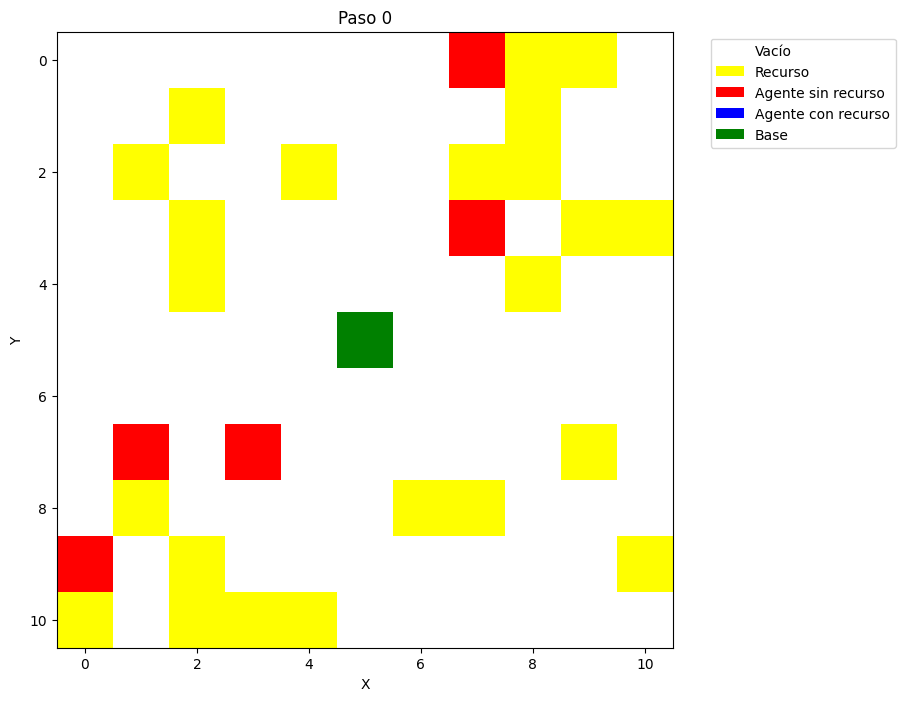

In [34]:
# Crear y ejecutar la simulación
model = ExploradorModel(width=11, height=11, agents=5, resources=20)

# Ejecutar N pasos
steps = 200
for i in range(steps):
    model.step()

# Obtener datos del DataCollector
model_data = model.datacollector.get_model_vars_dataframe()
grids = model_data["Grid"]

# TODA ESTA PARTE DE LA ANIMACIÓN LA HICE CON CHATGPT

# Crear animación
fig, ax = plt.subplots(figsize=(8, 8))

# Crear colormap personalizado
colors = ['white', 'yellow', 'red', 'blue', 'green']  
# 0=vacío, 1=recurso, 2=agente sin recurso, 3=agente con recurso, 4=base
cmap = plt.cm.colors.ListedColormap(colors)

def animate(frame):
    ax.clear()
    grid = grids.iloc[frame]
    
    # Mostrar grid
    # 0 = vacío, 1 = recurso, 2 = agente
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=4, animated=True)
    ax.set_title(f"Paso {frame}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    # Agregar leyendas
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='white', label='Vacío'),
        Patch(facecolor='yellow', label='Recurso'),
        Patch(facecolor='red', label='Agente sin recurso'),
        Patch(facecolor='blue', label='Agente con recurso'),
        Patch(facecolor='green', label='Base')
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))
    
    return [im]

# Crear animación
anim = animation.FuncAnimation(fig, animate, frames=len(grids), 
                               interval=200, blit=True, repeat=True)

plt.show()

In [36]:
anim